[np.float64(2.4684068094579303), np.float64(3.335704974161037), np.float64(4.783279375373183), np.float64(6.2795873320876145), np.float64(8.080776465019055), np.float64(10.25116303229294), np.float64(12.9360635066099), np.float64(16.276861327786712), np.float64(20.454829618345983), np.float64(25.688972842084684), np.float64(32.25315718048336), np.float64(40.48895641683869), np.float64(50.824407307019094), np.float64(63.79612654485427), np.float64(80.07737014308985), np.float64(100.51298922051251), np.float64(126.16331847536827), np.float64(158.3592064825883), np.float64(198.77107967611957), np.float64(249.495615421267)]


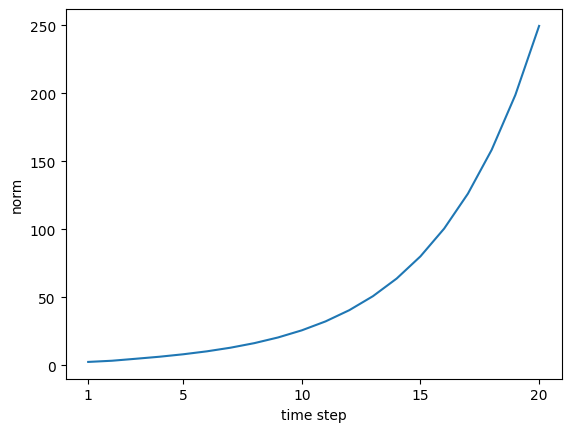

In [1]:
# ゲート付きRNN
# RNNの問題点
# RNNの復習
# 勾配消失・勾配爆発
# ➡ 原因
import numpy as np
import matplotlib.pyplot as plt


N = 2  # ミニバッチサイズ
H = 3  # 隠れ状態ベクトルの次元数
T = 20  # 時系列データの長さ

dh = np.ones((N, H))

np.random.seed(3)

Wh = np.random.randn(H, H)
#Wh = np.random.randn(H, H) * 0.5

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

print(norm_list)

# グラフの描画
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('time step')
plt.ylabel('norm')
plt.show()

In [ ]:
# 勾配爆発への対策
import numpy as np


dW1 = np.random.rand(3, 3) * 10
dW2 = np.random.rand(3, 3) * 10
# 勾配のリスト
grads = [dW1, dW2]
# しきい値
max_norm = 5.0


def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)  # 全ての要素を2乗して足す 
    total_norm = np.sqrt(total_norm)     # ルートを掛ける（ノルム完成）

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate


print('before:', dW1.flatten())
clip_grads(grads, max_norm)
print('after:', dW1.flatten())

before: [6.49144048 2.78487283 6.76254902 5.90862817 0.23981882 5.58854088
 2.59252447 4.15101197 2.83525082]
after: [1.49503731 0.64138134 1.55747605 1.36081038 0.05523244 1.28709139
 0.59708178 0.95601551 0.65298384]
